# Projeto: Previsão de expansão de luzes noturnas com imagens VIIRS NTL

Este notebook é um **protótipo acadêmico em Google Colab** para prever a expansão da área iluminada em regiões litorâneas usando imagens mensais `.tif` de luzes noturnas de **2015 a 2025**.

Nesta versão, o notebook assume que os dados estão organizados em **pastas por ano**, e não em pastas por cidade/região. A região é identificada pelo **nome do arquivo**.

Exemplo:

```text
ntl_dados/
├── 2015/
│   ├── VIIRS_NTL_MedianaMensal_Blumenau_2015_01_reprojetada.tif
│   ├── VIIRS_NTL_MedianaMensal_Criciuma_2015_01_reprojetada.tif
│   └── ...
├── 2016/
│   ├── VIIRS_NTL_MedianaMensal_Blumenau_2016_01_reprojetada.tif
│   └── ...
└── 2025/
```

O fluxo foi montado para mostrar visualmente cada etapa:

1. leitura dos `.tif` e, quando existir, dos `.tif.aux.xml`;
2. inspeção dos valores de radiância;
3. normalização robusta com `log1p`;
4. segmentação da área iluminada;
5. cálculo da área iluminada mensal por região;
6. baseline temporal por região;
7. modelo espacial leve de tendência/persistência;
8. previsão recursiva dos meses seguintes.

> Observação: os arquivos `.aux.xml` são tratados como opcionais. O raster principal é sempre o `.tif`.


## Artigo-base usado como referência

Artigo principal sugerido:

**Chakraborty, S.; Stokes, E. C. (2023). _Adaptive Modeling of Satellite-Derived Nighttime Lights Time-Series for Tracking Urban Change Processes Using Machine Learning_. Remote Sensing of Environment.**

Ideia aproveitada no projeto: aprender a dinâmica temporal das luzes noturnas e usar previsões para acompanhar mudanças urbanas.

Adaptação usada no protótipo:

- previsão temporal agregada da área iluminada;
- previsão espacial simples, baseada na persistência e na tendência recente das máscaras.

Esta versão evita bibliotecas pesadas de rede neural para manter o projeto mais fácil de executar no Colab.


## 1. Instalação das bibliotecas

No Colab, execute esta célula uma vez. Se o ambiente pedir reinicialização, reinicie e rode novamente a partir dos imports.

In [61]:
!pip -q install rasterio tqdm statsmodels opencv-python-headless scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports e configuração inicial

In [62]:
from pathlib import Path
import re
import os
import math
import warnings
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import rasterio
from rasterio.errors import NotGeoreferencedWarning

import cv2

warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 5)

print('Ambiente carregado.')

Ambiente carregado.


## 3. Conectar ao Google Drive e definir pasta dos dados

Neste notebook, considere que os arquivos estão organizados **apenas em subpastas de ano**.

A estrutura esperada no Google Drive é:

```text
/content/drive/MyDrive/ntl_dados/
├── 2015/
│   ├── VIIRS_NTL_MedianaMensal_Blumenau_2015_01_reprojetada.tif
│   ├── VIIRS_NTL_MedianaMensal_Blumenau_2015_02_reprojetada.tif
│   ├── VIIRS_NTL_MedianaMensal_Criciuma_2015_01_reprojetada.tif
│   ├── VIIRS_NTL_MedianaMensal_Florianopolis_2015_01_reprojetada.tif
│   └── ...
├── 2016/
│   ├── VIIRS_NTL_MedianaMensal_Blumenau_2016_01_reprojetada.tif
│   └── ...
├── 2017/
└── ...
```

Ou seja: **não precisa existir pasta da cidade**.

A cidade/região será extraída do nome do arquivo, por exemplo:

```text
VIIRS_NTL_MedianaMensal_Blumenau_2022_01_reprojetada.tif
```

gera:

- região: `Blumenau`;
- ano: `2022`;
- mês: `01`.

> Os arquivos `.tif.aux.xml` podem estar na mesma pasta do `.tif`. Eles são opcionais e podem existir só para algumas regiões.


In [63]:
BASE_DIR = os.getcwd()

DATA_DIR = Path(BASE_DIR, 'data', 'NTL_LITORAL_SC', 'QGIS_LITORAL', 'RASTER', 'NTL_LITORAL')

# Pasta onde os resultados serão salvos dentro do Colab
OUTPUT_DIR = Path(BASE_DIR, 'resultados')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Pasta raiz dos dados:', DATA_DIR)
print('Pasta de saída:', OUTPUT_DIR)

pastas_ano = [p for p in DATA_DIR.iterdir() if p.is_dir()]
for p in sorted(pastas_ano):
    qtd_tif = len(list(p.glob('*.tif')))
    print(f' - {p.name}: {qtd_tif} arquivo(s) .tif')



Pasta raiz dos dados: c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\data\NTL_LITORAL_SC\QGIS_LITORAL\RASTER\NTL_LITORAL
Pasta de saída: c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\resultados
 - NTL_2015: 48 arquivo(s) .tif
 - NTL_2016: 48 arquivo(s) .tif
 - NTL_2017: 48 arquivo(s) .tif
 - NTL_2018: 48 arquivo(s) .tif
 - NTL_2019: 48 arquivo(s) .tif
 - NTL_2020: 48 arquivo(s) .tif
 - NTL_2021: 48 arquivo(s) .tif
 - NTL_2022: 48 arquivo(s) .tif
 - NTL_2023: 48 arquivo(s) .tif
 - NTL_2024: 48 arquivo(s) .tif
 - NTL_2025: 48 arquivo(s) .tif


## 4. Catalogar os arquivos disponíveis

Esta etapa cria uma tabela com todos os rasters encontrados nas pastas de ano, indicando:

- região extraída do **nome do arquivo**;
- ano e mês extraídos do **nome do arquivo**;
- ano encontrado na **pasta**;
- caminho relativo dentro da pasta raiz;
- existência ou não de `.aux.xml` correspondente.

Assim, o notebook funciona para uma estrutura simples como:

```text
ntl_dados/2015/*.tif
ntl_dados/2016/*.tif
...
ntl_dados/2025/*.tif
```

A conferência `ano_pasta_confere` ajuda a detectar erros, por exemplo um arquivo com `2022` no nome salvo por engano dentro da pasta `2021`.


In [64]:
PADRAO_NOME = re.compile(
    r'VIIRS_NTL_MedianaMensal_(?P<regiao>.+?)_(?P<ano>\d{4})_(?P<mes>\d{2})_reprojetada\.tif$',
    re.IGNORECASE
)


def encontrar_ano_no_caminho(path: Path):
    """Procura uma pasta com formato YYYY no caminho do arquivo."""
    for parte in reversed(path.parts):
        if re.fullmatch(r'20\d{2}', parte):
            return int(parte)
    return None


def encontrar_arquivo_aux(tif_path: Path):
    """Procura variações comuns do arquivo auxiliar do GDAL na mesma pasta do .tif."""
    candidatos = [
        Path(str(tif_path) + '.aux.xml'),
        tif_path.with_suffix(tif_path.suffix + '.aux.xml'),
        Path(str(tif_path) + '.aux(1).xml'),
    ]
    for c in candidatos:
        if c.exists():
            return c

    # fallback: qualquer arquivo que comece com o nome do tif e termine em .xml
    encontrados = list(tif_path.parent.glob(tif_path.name + '*.xml'))
    return encontrados[0] if encontrados else None


def montar_catalogo(data_dir: Path):
    linhas = []

    # Procura recursivamente. Mesmo que a estrutura esperada seja data_dir/ANO/*.tif,
    # o rglob deixa o notebook mais tolerante caso alguma pasta extra exista.
    tif_files = sorted([
        p for p in data_dir.rglob('*.tif')
        if not str(p).lower().endswith('.aux.xml')
    ])

    arquivos_ignorados = []
    for p in tif_files:
        m = PADRAO_NOME.search(p.name)
        if not m:
            arquivos_ignorados.append(str(p.relative_to(data_dir)))
            continue

        regiao = m.group('regiao')
        ano_nome = int(m.group('ano'))
        mes = int(m.group('mes'))
        ano_pasta = encontrar_ano_no_caminho(p.parent)
        aux = encontrar_arquivo_aux(p)

        linhas.append({
            'regiao': regiao,
            'ano': ano_nome,
            'mes': mes,
            'data': pd.Timestamp(year=ano_nome, month=mes, day=1),
            'ano_pasta': ano_pasta,
            'ano_pasta_confere': (ano_pasta == ano_nome) if ano_pasta is not None else None,
            'caminho_relativo': str(p.relative_to(data_dir)),
            'tif_path': str(p),
            'aux_path': str(aux) if aux else None,
            'tem_aux_xml': aux is not None,
        })

    df = pd.DataFrame(linhas)
    if len(df) == 0:
        raise FileNotFoundError(
            f'Nenhum .tif compatível encontrado em {data_dir}. '
            'Confira DATA_DIR e o padrão do nome dos arquivos.'
        )

    if arquivos_ignorados:
        print('Arquivos .tif ignorados por não seguirem o padrão esperado:')
        for arq in arquivos_ignorados[:20]:
            print(' -', arq)
        if len(arquivos_ignorados) > 20:
            print(f'... e mais {len(arquivos_ignorados) - 20} arquivo(s).')

    return df.sort_values(['regiao', 'ano', 'mes']).reset_index(drop=True)


catalogo = montar_catalogo(DATA_DIR)
print('Total de imagens encontradas:', len(catalogo))
display(catalogo.head(10))

print('\nRegiões detectadas pelo nome dos arquivos:')
display(pd.DataFrame({'regiao': sorted(catalogo['regiao'].unique())}))

print('\nCobertura por região e ano:')
cobertura = catalogo.pivot_table(index='regiao', columns='ano', values='mes', aggfunc='count', fill_value=0)
display(cobertura)

print('\nConferência do ano no nome do arquivo x ano da pasta:')
if catalogo['ano_pasta'].notna().any():
    display(catalogo[['regiao', 'ano', 'mes', 'ano_pasta', 'ano_pasta_confere', 'caminho_relativo']].head(20))
    inconsistentes = catalogo[catalogo['ano_pasta_confere'] == False]
    if len(inconsistentes) > 0:
        print('ATENÇÃO: existem arquivos em subpastas de ano diferente do ano no nome.')
        display(inconsistentes[['regiao', 'ano', 'mes', 'ano_pasta', 'caminho_relativo']])
else:
    print('Nenhuma subpasta com formato YYYY foi detectada no caminho. Isso não impede o notebook de rodar, mas confira a organização.')

print('\nQuantidade de .aux.xml por região:')
display(catalogo.groupby('regiao')['tem_aux_xml'].agg(['sum', 'count']))

print('\nMeses encontrados por região/ano. O ideal é 12 por ano:')
meses_por_ano = (
    catalogo
    .groupby(['regiao', 'ano'])['mes']
    .agg(count='count', meses=lambda x: sorted(x))
    .reset_index()
)
display(meses_por_ano)

faltantes = []
for (regiao, ano), grupo in catalogo.groupby(['regiao', 'ano']):
    meses = set(grupo['mes'])
    faltam = sorted(set(range(1, 13)) - meses)
    if faltam:
        faltantes.append({'regiao': regiao, 'ano': ano, 'meses_faltantes': faltam})

if faltantes:
    print('\nAtenção: alguns anos/regiões não têm os 12 meses completos.')
    display(pd.DataFrame(faltantes))
else:
    print('\nTodas as combinações região/ano encontradas possuem 12 meses.')


Arquivos .tif ignorados por não seguirem o padrão esperado:
 - NTL_2017\VIIRS_NTL_MedianaMensal_Florianopolis_2017_03__reprojetada.tif
 - NTL_2018\VIIRS_NTL_MedianaMensal_Blumenau_2018_08__reprojetada.tif
 - NTL_2018\VIIRS_NTL_MedianaMensal_Florianopolis_2018_07__reprojetada.tif
 - NTL_2019\VIIRS_NTL_MedianaMensal_Florianopolis_2019_12__reprojetada.tif
 - NTL_2025\VIIRS_NTL_MedianaMensal_Florianopolis_2025_11__reprojetada.tif
Total de imagens encontradas: 523


,regiao,ano,mes,data,ano_pasta,ano_pasta_confere,caminho_relativo,tif_path,aux_path,tem_aux_xml
0,Blumenau,2015,1,2015-01-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
1,Blumenau,2015,2,2015-02-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
2,Blumenau,2015,3,2015-03-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
3,Blumenau,2015,4,2015-04-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
4,Blumenau,2015,5,2015-05-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
5,Blumenau,2015,6,2015-06-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
6,Blumenau,2015,7,2015-07-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
7,Blumenau,2015,8,2015-08-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
8,Blumenau,2015,9,2015-09-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False
9,Blumenau,2015,10,2015-10-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False



Regiões detectadas pelo nome dos arquivos:


,regiao
0,Blumenau
1,Criciuma
2,Florianopolis
3,Joinville



Cobertura por região e ano:


...

,sum,count
regiao,,
Blumenau,0,131
Criciuma,83,132
Florianopolis,1,128
Joinville,83,132



Meses encontrados por região/ano. O ideal é 12 por ano:


,regiao,ano,count,meses
0,Blumenau,2015,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,Blumenau,2016,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
2,Blumenau,2017,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,Blumenau,2018,11,"[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12]"
4,Blumenau,2019,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
5,Blumenau,2020,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,Blumenau,2021,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,Blumenau,2022,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
8,Blumenau,2023,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
9,Blumenau,2024,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"



Atenção: alguns anos/regiões não têm os 12 meses completos.


,regiao,ano,meses_faltantes
0,Blumenau,2018,[8]
1,Florianopolis,2017,[3]
2,Florianopolis,2018,[7]
3,Florianopolis,2019,[12]
4,Florianopolis,2025,[11]


## 5. Ler estatísticas dos `.aux.xml` quando existirem

No seu caso, os `.aux.xml` normalmente guardam estatísticas como mínimo, máximo, média, desvio-padrão e percentual válido. Eles ajudam na auditoria, mas não são obrigatórios para treinar o modelo.

In [65]:
def ler_aux_xml(aux_path):
    if aux_path is None or pd.isna(aux_path):
        return {}
    aux_path = Path(aux_path)
    if not aux_path.exists():
        return {}
    try:
        root = ET.parse(aux_path).getroot()
        stats = {}
        for mdi in root.findall('.//MDI'):
            key = mdi.attrib.get('key')
            value = mdi.text
            if key:
                try:
                    stats[key] = float(value)
                except Exception:
                    stats[key] = value
        return stats
    except Exception as e:
        return {'erro_aux_xml': str(e)}

aux_linhas = []
for _, row in catalogo.iterrows():
    stats = ler_aux_xml(row['aux_path'])
    aux_linhas.append({
        'regiao': row['regiao'],
        'ano': row['ano'],
        'mes': row['mes'],
        'tem_aux_xml': row['tem_aux_xml'],
        **stats
    })

aux_df = pd.DataFrame(aux_linhas)
display(aux_df.head(10))

,regiao,ano,mes,tem_aux_xml,STATISTICS_MINIMUM,STATISTICS_MAXIMUM,STATISTICS_MEAN,STATISTICS_STDDEV,STATISTICS_VALID_PERCENT
0,Blumenau,2015,1,False,NaN,NaN,NaN,NaN,NaN
1,Blumenau,2015,2,False,NaN,NaN,NaN,NaN,NaN
2,Blumenau,2015,3,False,NaN,NaN,NaN,NaN,NaN
3,Blumenau,2015,4,False,NaN,NaN,NaN,NaN,NaN
4,Blumenau,2015,5,False,NaN,NaN,NaN,NaN,NaN
5,Blumenau,2015,6,False,NaN,NaN,NaN,NaN,NaN
6,Blumenau,2015,7,False,NaN,NaN,NaN,NaN,NaN
7,Blumenau,2015,8,False,NaN,NaN,NaN,NaN,NaN
8,Blumenau,2015,9,False,NaN,NaN,NaN,NaN,NaN
9,Blumenau,2015,10,False,NaN,NaN,NaN,NaN,NaN


## 6. Funções para ler e inspecionar os rasters `.tif`

In [66]:
def ler_raster(path):
    """Lê a primeira banda do raster como float32 e retorna imagem + metadados básicos."""
    path = Path(path)
    with rasterio.open(path) as src:
        img = src.read(1).astype(np.float32)
        meta = {
            'crs': str(src.crs),
            'transform': src.transform,
            'width': src.width,
            'height': src.height,
            'bounds': src.bounds,
            'nodata': src.nodata,
            'res': src.res,
        }
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    return img, meta


def resumo_raster(path):
    img, meta = ler_raster(path)
    valid = img[np.isfinite(img)]
    return {
        'shape': img.shape,
        'min': float(np.nanmin(valid)),
        'max': float(np.nanmax(valid)),
        'mean': float(np.nanmean(valid)),
        'std': float(np.nanstd(valid)),
        'p50': float(np.nanpercentile(valid, 50)),
        'p95': float(np.nanpercentile(valid, 95)),
        'p99': float(np.nanpercentile(valid, 99)),
        'crs': meta['crs'],
        'res': meta['res'],
    }

amostra = catalogo.iloc[0]
print('Amostra:', amostra['regiao'], amostra['ano'], amostra['mes'])
print(resumo_raster(amostra['tif_path']))

Amostra: Blumenau 2015 1
{'shape': (185, 101), 'min': -9999.0, 'max': 17899.69140625, 'mean': -452.5687561035156, 'std': 2097.706298828125, 'p50': 0.0, 'p95': 13.161149978637695, 'p99': 59.542903900146484, 'crs': 'EPSG:31982', 'res': (484.81225202677626, 484.81225202677626)}


## 7. Visualizar imagem bruta, `log1p` e histograma

Como luzes noturnas costumam ter cauda longa, a visualização linear pode esconder detalhes. Por isso usamos `log1p`.

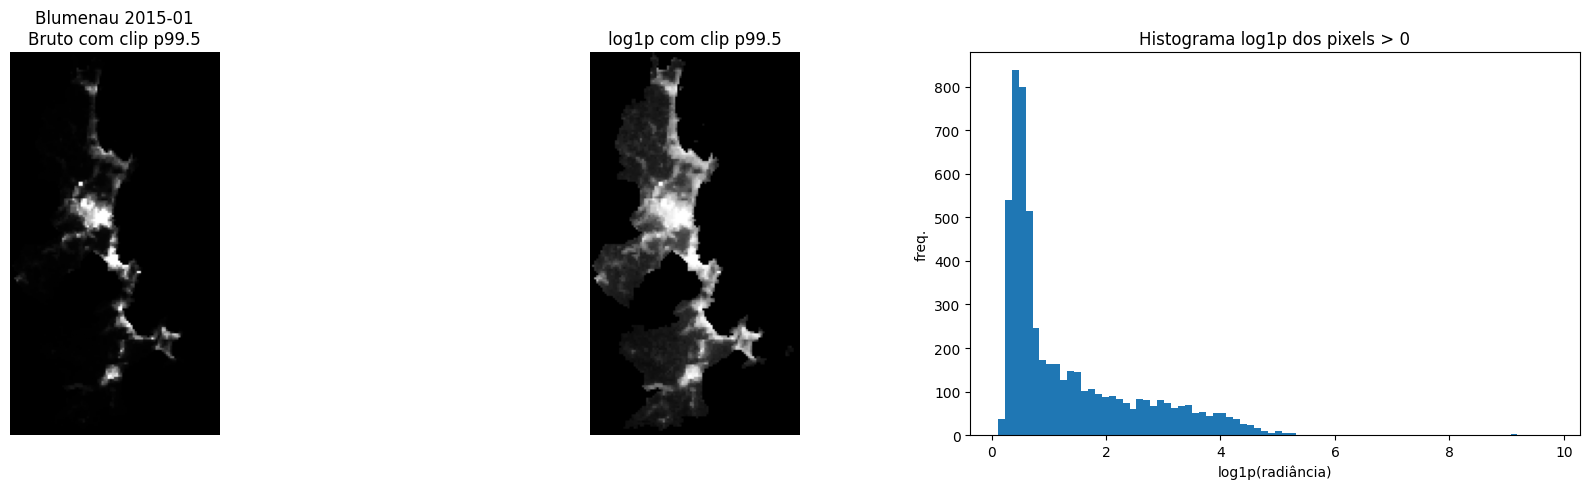

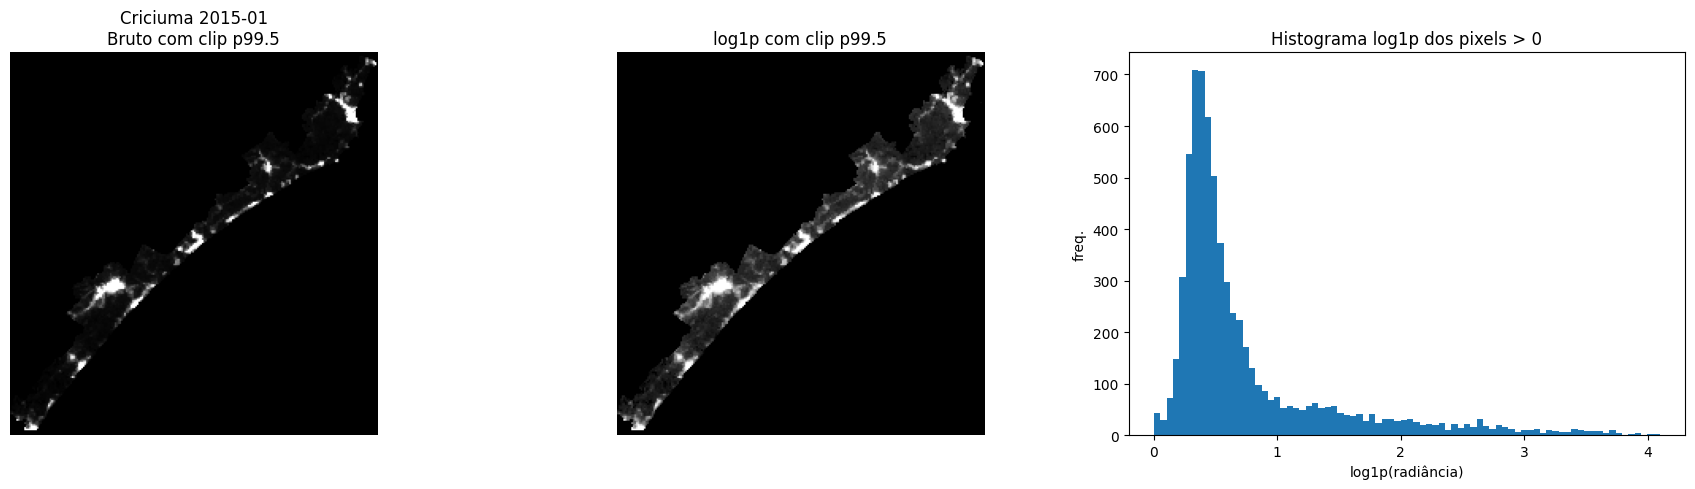

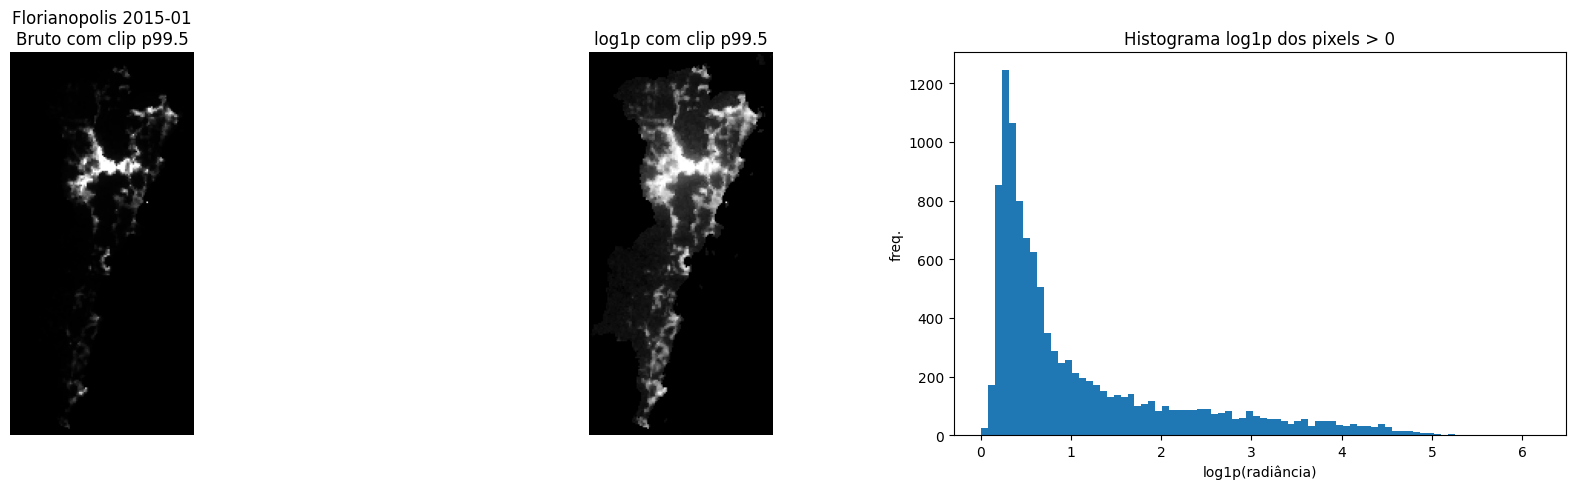

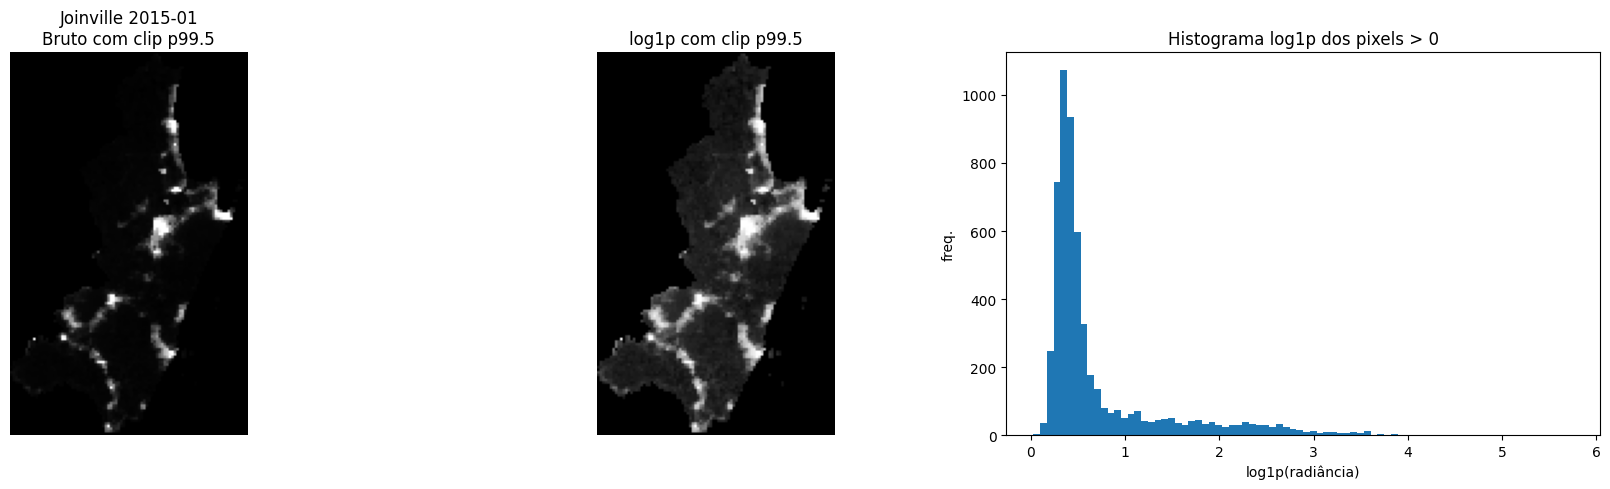

In [67]:
def visualizar_raster(path, titulo='Raster'):
    img, _ = ler_raster(path)
    img_log = np.log1p(np.clip(img, 0, None))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    p99 = np.percentile(img, 99.5)
    axes[0].imshow(np.clip(img, 0, p99), cmap='gray')
    axes[0].set_title(f'{titulo}\nBruto com clip p99.5')
    axes[0].axis('off')

    p99_log = np.percentile(img_log, 99.5)
    axes[1].imshow(np.clip(img_log, 0, p99_log), cmap='gray')
    axes[1].set_title('log1p com clip p99.5')
    axes[1].axis('off')

    vals = img[img > 0].ravel()
    if len(vals) > 0:
        axes[2].hist(np.log1p(vals), bins=80)
    axes[2].set_title('Histograma log1p dos pixels > 0')
    axes[2].set_xlabel('log1p(radiância)')
    axes[2].set_ylabel('freq.')

    plt.tight_layout()
    plt.show()

for regiao in catalogo['regiao'].unique():
    row = catalogo[catalogo['regiao'] == regiao].iloc[0]
    visualizar_raster(row['tif_path'], f"{regiao} {row['ano']}-{row['mes']:02d}")

## 8. Normalização robusta e limiar de área iluminada

A ideia é transformar a radiância contínua em uma **máscara binária** de área iluminada.

Estratégia usada:

- remover valores negativos;
- aplicar `log1p`;
- calcular um valor máximo robusto por região usando percentil dos anos de treino;
- normalizar para 0–1;
- estimar limiar por região com Otsu, usando apenas imagens de treino.

Isso evita que o limiar mude todo mês e confunda variação de aquisição com expansão.

In [68]:
ANO_TREINO_FIM = 2023
PERCENTIL_CLIP = 99.5
LIMIAR_MINIMO = 0.08
PIXEL_AREA_KM2_FALLBACK = (463.83 ** 2) / 1_000_000  # aprox. produto VIIRS em grade ~463,83m


def area_pixel_km2(meta):
    """Calcula área aproximada do pixel em km² quando o CRS está projetado.
    Se estiver em graus ou ausente, usa fallback VIIRS.
    """
    resx, resy = meta.get('res', (None, None))
    crs = meta.get('crs', '')
    if resx is not None and resy is not None:
        # se a resolução parece estar em metros, usa direto
        if abs(resx) > 1 and abs(resy) > 1:
            return abs(resx * resy) / 1_000_000
    return PIXEL_AREA_KM2_FALLBACK


def coletar_pixels_log(paths, max_pixels_por_imagem=25000):
    valores = []
    for path in tqdm(paths, desc='Coletando pixels para parâmetros'):
        img, _ = ler_raster(path)
        img = np.clip(img, 0, None)
        vals = np.log1p(img[img > 0]).ravel()
        if len(vals) == 0:
            continue
        if len(vals) > max_pixels_por_imagem:
            idx = np.random.choice(len(vals), size=max_pixels_por_imagem, replace=False)
            vals = vals[idx]
        valores.append(vals.astype(np.float32))
    if not valores:
        return np.array([0, 1], dtype=np.float32)
    return np.concatenate(valores)


def calcular_parametros_regiao(df_regiao):
    treino = df_regiao[df_regiao['ano'] <= ANO_TREINO_FIM]
    pixels_log = coletar_pixels_log(treino['tif_path'].tolist())
    clip_hi = float(np.percentile(pixels_log, PERCENTIL_CLIP))
    clip_hi = max(clip_hi, 1e-6)

    pixels_norm = np.clip(pixels_log, 0, clip_hi) / clip_hi
    pixels_uint8 = (pixels_norm * 255).astype(np.uint8)
    if len(np.unique(pixels_uint8)) > 1:
        otsu, _ = cv2.threshold(pixels_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        limiar = float(otsu / 255.0)
    else:
        limiar = 0.20

    limiar = max(limiar, LIMIAR_MINIMO)
    return {'clip_hi_log': clip_hi, 'limiar_norm': limiar}


def normalizar_img(img, clip_hi_log):
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    img = np.clip(img, 0, None)
    img_log = np.log1p(img)
    img_norm = np.clip(img_log, 0, clip_hi_log) / clip_hi_log
    return img_norm.astype(np.float32)


def gerar_mascara(path, params):
    img, meta = ler_raster(path)
    img_norm = normalizar_img(img, params['clip_hi_log'])
    mascara = (img_norm >= params['limiar_norm']).astype(np.uint8)
    return img_norm, mascara, meta

params_regiao = {}
for regiao, df_regiao in catalogo.groupby('regiao'):
    print(f'Calculando parâmetros para {regiao}...')
    params_regiao[regiao] = calcular_parametros_regiao(df_regiao)

pd.DataFrame.from_dict(params_regiao, orient='index')

Calculando parâmetros para Blumenau...


Coletando pixels para parâmetros: 100%|██████████| 107/107 [00:00<00:00, 207.58it/s]


Calculando parâmetros para Criciuma...


Coletando pixels para parâmetros: 100%|██████████| 108/108 [00:00<00:00, 184.76it/s]


Calculando parâmetros para Florianopolis...


Coletando pixels para parâmetros: 100%|██████████| 105/105 [00:00<00:00, 219.16it/s]


Calculando parâmetros para Joinville...


Coletando pixels para parâmetros: 100%|██████████| 108/108 [00:00<00:00, 224.39it/s]


,clip_hi_log,limiar_norm
Blumenau,4.711409,0.407843
Criciuma,3.723782,0.372549
Florianopolis,4.710341,0.384314
Joinville,3.683166,0.372549


## 9. Gerar métricas mensais: pixels iluminados e área iluminada

Gerando máscaras e séries: 100%|██████████| 523/523 [00:02<00:00, 238.86it/s]

Série salva em: c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\resultados\serie_area_iluminada.csv


,regiao,ano,mes,data,ano_pasta,ano_pasta_confere,caminho_relativo,tif_path,aux_path,tem_aux_xml,height,width,pixel_area_km2,lit_pixels,area_iluminada_km2,clip_hi_log,limiar_norm
0,Blumenau,2015,1,2015-01-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False,185,101,0.235043,1414,332.350688,4.711409,0.407843
1,Blumenau,2015,2,2015-02-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False,185,101,0.235043,1426,335.171204,4.711409,0.407843
2,Blumenau,2015,3,2015-03-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False,185,101,0.235043,1425,334.936161,4.711409,0.407843
3,Blumenau,2015,4,2015-04-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False,185,101,0.235043,1501,352.799422,4.711409,0.407843
4,Blumenau,2015,5,2015-05-01,None,None,NTL_2015\VIIRS_NTL_MedianaMensal_Blumenau_2015...,c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Proc...,NaN,False,185,101,0.235043,1437,337.756676,4.711409,0.407843


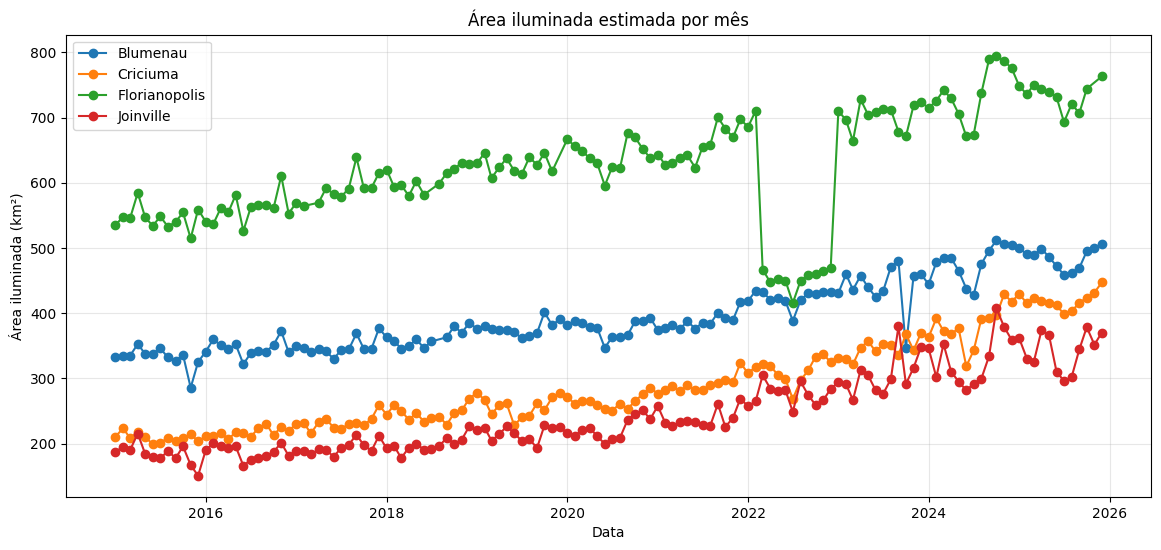

In [69]:
linhas = []
for _, row in tqdm(catalogo.iterrows(), total=len(catalogo), desc='Gerando máscaras e séries'):
    regiao = row['regiao']
    params = params_regiao[regiao]
    img_norm, mascara, meta = gerar_mascara(row['tif_path'], params)
    pix_area = area_pixel_km2(meta)
    lit_pixels = int(mascara.sum())
    area_km2 = lit_pixels * pix_area
    linhas.append({
        **row.to_dict(),
        'height': mascara.shape[0],
        'width': mascara.shape[1],
        'pixel_area_km2': pix_area,
        'lit_pixels': lit_pixels,
        'area_iluminada_km2': area_km2,
        'clip_hi_log': params['clip_hi_log'],
        'limiar_norm': params['limiar_norm'],
    })

serie_df = pd.DataFrame(linhas).sort_values(['regiao', 'data']).reset_index(drop=True)
serie_csv = OUTPUT_DIR / 'serie_area_iluminada.csv'
serie_df.to_csv(serie_csv, index=False)
print('Série salva em:', serie_csv)
display(serie_df.head())

plt.figure(figsize=(14, 6))
for regiao, df_regiao in serie_df.groupby('regiao'):
    plt.plot(df_regiao['data'], df_regiao['area_iluminada_km2'], marker='o', label=regiao)
plt.title('Área iluminada estimada por mês')
plt.xlabel('Data')
plt.ylabel('Área iluminada (km²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Visualizar a máscara gerada para cada região

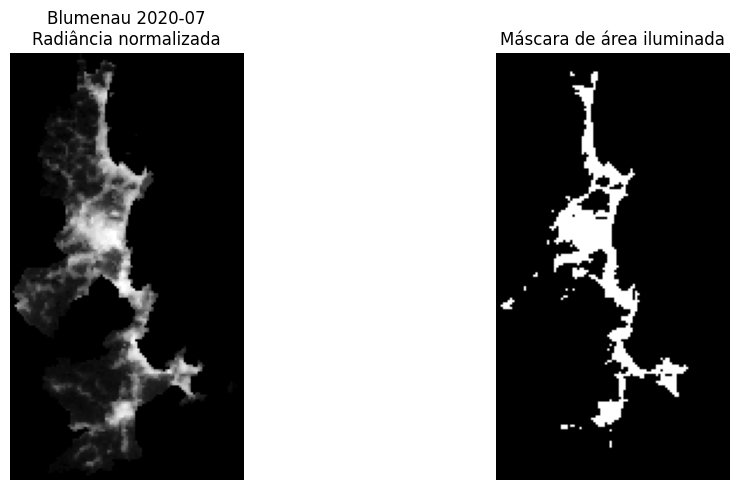

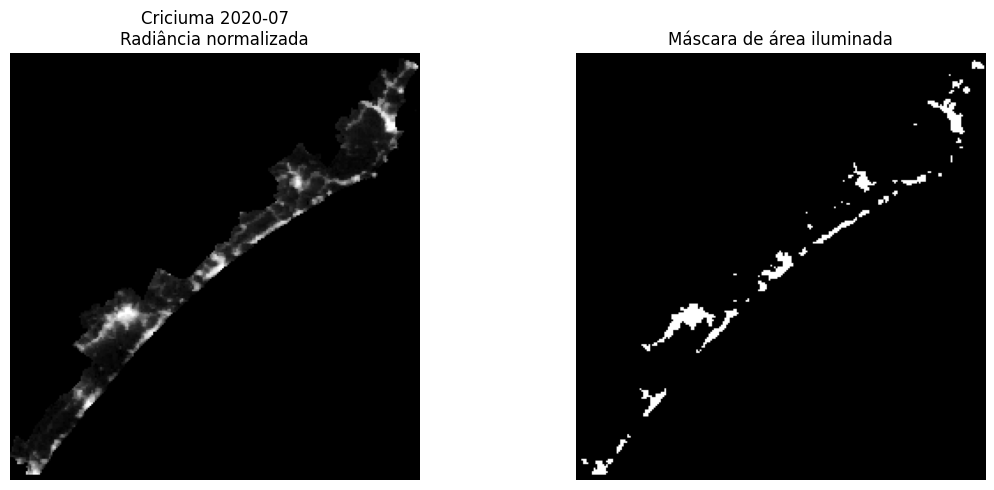

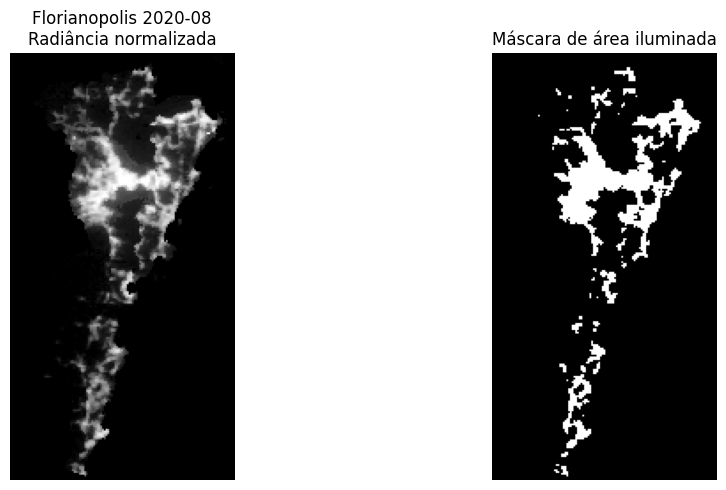

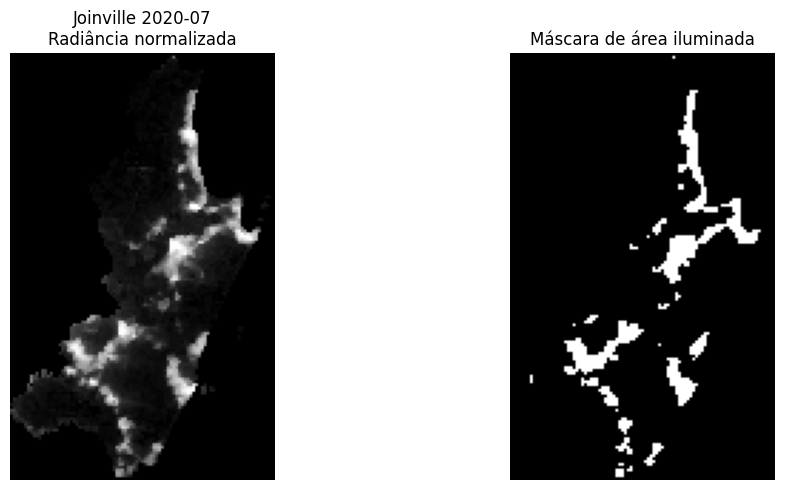

In [70]:
def visualizar_mascara(row):
    regiao = row['regiao']
    params = params_regiao[regiao]
    img_norm, mascara, _ = gerar_mascara(row['tif_path'], params)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_norm, cmap='gray')
    axes[0].set_title(f'{regiao} {row["ano"]}-{row["mes"]:02d}\nRadiância normalizada')
    axes[0].axis('off')

    axes[1].imshow(mascara, cmap='gray')
    axes[1].set_title('Máscara de área iluminada')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

for regiao in serie_df['regiao'].unique():
    row = serie_df[serie_df['regiao'] == regiao].iloc[len(serie_df[serie_df['regiao'] == regiao]) // 2]
    visualizar_mascara(row)

## 11. Baseline temporal por região

Antes da rede neural espacial, é importante ter um baseline simples. Ele serve como comparação e já gera resultados para entregar rapidamente.

Modelos:

- **Sazonal ingênuo**: prevê o mesmo valor observado 12 meses antes.
- **Holt-Winters/ETS**: modelo estatístico com tendência e sazonalidade anual, quando houver dados suficientes.

Divisão sugerida:

- treino: 2015–2023;
- validação: 2024;
- teste: 2025;
- previsão futura: 2026.

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    TEM_STATSMODELS = True
except Exception:
    TEM_STATSMODELS = False


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def mape_seguro(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-6, np.nan, np.abs(y_true))
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100)


def previsao_sazonal_naive(serie, datas_futuras):
    # para cada mês futuro, usa o valor de 12 meses antes quando existir
    s = pd.Series(serie['area_iluminada_km2'].values, index=serie['data'])
    preds = []
    for d in datas_futuras:
        ref = d - pd.DateOffset(years=1)
        if ref in s.index:
            preds.append(float(s.loc[ref]))
        else:
            preds.append(float(s.iloc[-1]))
    return np.array(preds)


def treinar_ets_e_prever(treino, n_passos):
    if not TEM_STATSMODELS or len(treino) < 36:
        return None
    y = treino['area_iluminada_km2'].astype(float).values
    try:
        modelo = ExponentialSmoothing(
            y,
            trend='add',
            seasonal='add',
            seasonal_periods=12,
            initialization_method='estimated'
        ).fit(optimized=True)
        return np.asarray(modelo.forecast(n_passos), dtype=float)
    except Exception as e:
        print('ETS falhou:', e)
        return None

resultados_baseline = []
previsoes_baseline = []

for regiao, df_regiao in serie_df.groupby('regiao'):
    df_regiao = df_regiao.sort_values('data').reset_index(drop=True)
    treino = df_regiao[df_regiao['ano'] <= 2023]
    val = df_regiao[df_regiao['ano'] == 2024]
    teste = df_regiao[df_regiao['ano'] == 2025]

    for nome_split, split_df in [('val_2024', val), ('teste_2025', teste)]:
        if len(split_df) == 0:
            continue
        y_true = split_df['area_iluminada_km2'].values
        pred_naive = previsao_sazonal_naive(df_regiao[df_regiao['data'] < split_df['data'].min()], split_df['data'])
        resultados_baseline.append({
            'regiao': regiao,
            'split': nome_split,
            'modelo': 'sazonal_naive',
            'MAE': mean_absolute_error(y_true, pred_naive),
            'RMSE': rmse(y_true, pred_naive),
            'MAPE_%': mape_seguro(y_true, pred_naive),
        })
        previsoes_baseline.append(pd.DataFrame({
            'regiao': regiao,
            'split': nome_split,
            'modelo': 'sazonal_naive',
            'data': split_df['data'].values,
            'real': y_true,
            'previsto': pred_naive,
        }))

    # ETS: treina só em 2015-2023 para validar 2024 e em 2015-2024 para testar 2025
    for nome_split, train_df, split_df in [
        ('val_2024', treino, val),
        ('teste_2025', df_regiao[df_regiao['ano'] <= 2024], teste),
    ]:
        if len(split_df) == 0:
            continue
        pred_ets = treinar_ets_e_prever(train_df, len(split_df))
        if pred_ets is None:
            continue
        y_true = split_df['area_iluminada_km2'].values
        resultados_baseline.append({
            'regiao': regiao,
            'split': nome_split,
            'modelo': 'ETS_HoltWinters',
            'MAE': mean_absolute_error(y_true, pred_ets),
            'RMSE': rmse(y_true, pred_ets),
            'MAPE_%': mape_seguro(y_true, pred_ets),
        })
        previsoes_baseline.append(pd.DataFrame({
            'regiao': regiao,
            'split': nome_split,
            'modelo': 'ETS_HoltWinters',
            'data': split_df['data'].values,
            'real': y_true,
            'previsto': pred_ets,
        }))

metricas_baseline = pd.DataFrame(resultados_baseline)
display(metricas_baseline.sort_values(['regiao', 'split', 'RMSE']))

if previsoes_baseline:
    previsoes_baseline_df = pd.concat(previsoes_baseline, ignore_index=True)
    display(previsoes_baseline_df.head())
else:
    previsoes_baseline_df = pd.DataFrame()
    print('Sem previsões de baseline geradas.')

,regiao,split,modelo,MAE,RMSE,MAPE_%
3,Blumenau,teste_2025,ETS_HoltWinters,15.822473,19.525748,3.328699
1,Blumenau,teste_2025,sazonal_naive,19.879922,24.559822,4.121707
2,Blumenau,val_2024,ETS_HoltWinters,28.055951,32.939651,5.717716
0,Blumenau,val_2024,sazonal_naive,35.825250,55.023044,7.253890
7,Criciuma,teste_2025,ETS_HoltWinters,6.355591,7.751134,1.520414
5,Criciuma,teste_2025,sazonal_naive,39.352930,46.241036,9.415403
6,Criciuma,val_2024,ETS_HoltWinters,22.870811,27.420522,5.916263
4,Criciuma,val_2024,sazonal_naive,39.752083,44.929430,10.204629
9,Florianopolis,teste_2025,sazonal_naive,31.112063,38.601652,4.268177
11,Florianopolis,teste_2025,ETS_HoltWinters,56.362121,59.651584,7.736883


,regiao,split,modelo,data,real,previsto
0,Blumenau,val_2024,sazonal_naive,2024-01-01,444.475664,430.833672
1,Blumenau,val_2024,sazonal_naive,2024-02-01,478.312342,459.978994
2,Blumenau,val_2024,sazonal_naive,2024-03-01,483.953372,436.004616
3,Blumenau,val_2024,sazonal_naive,2024-04-01,484.658500,457.628565
4,Blumenau,val_2024,sazonal_naive,2024-05-01,465.149938,439.765303


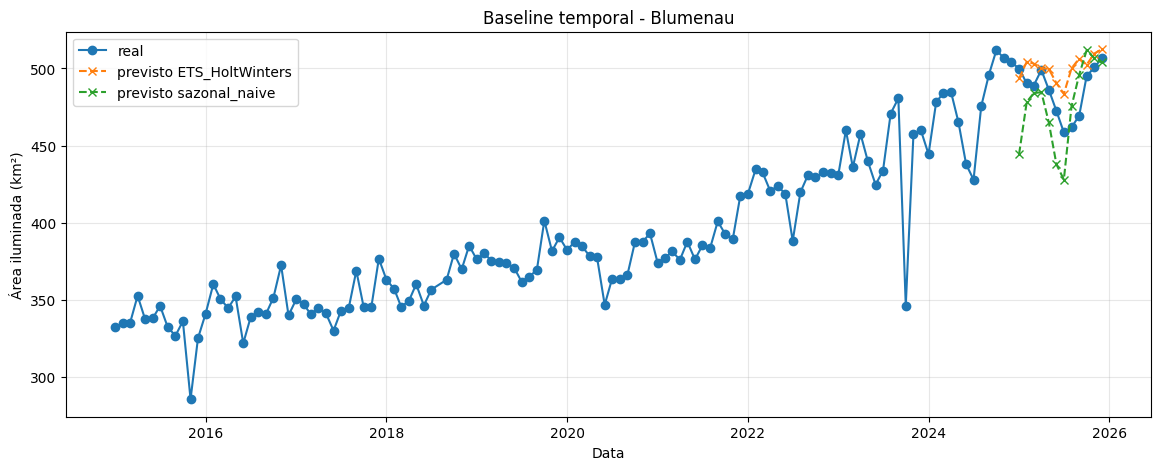

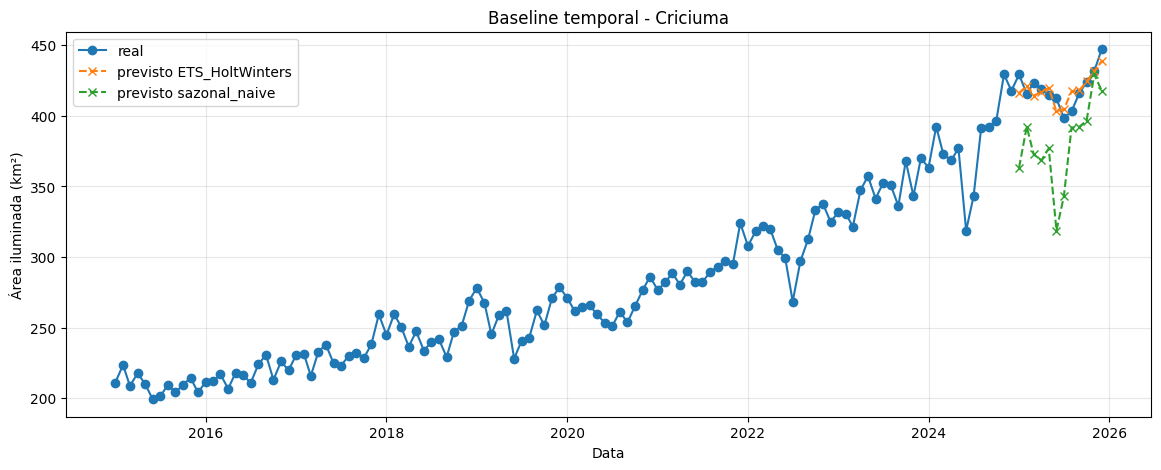

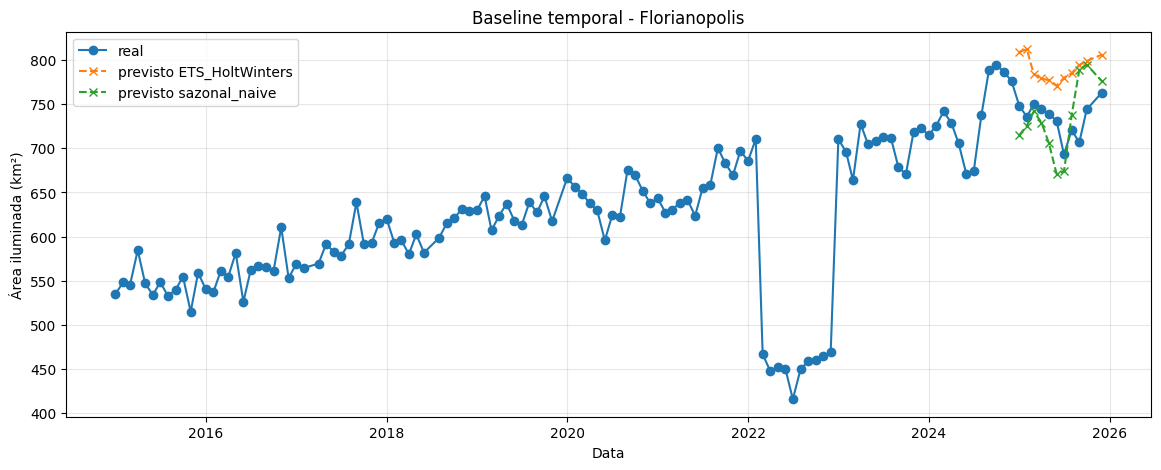

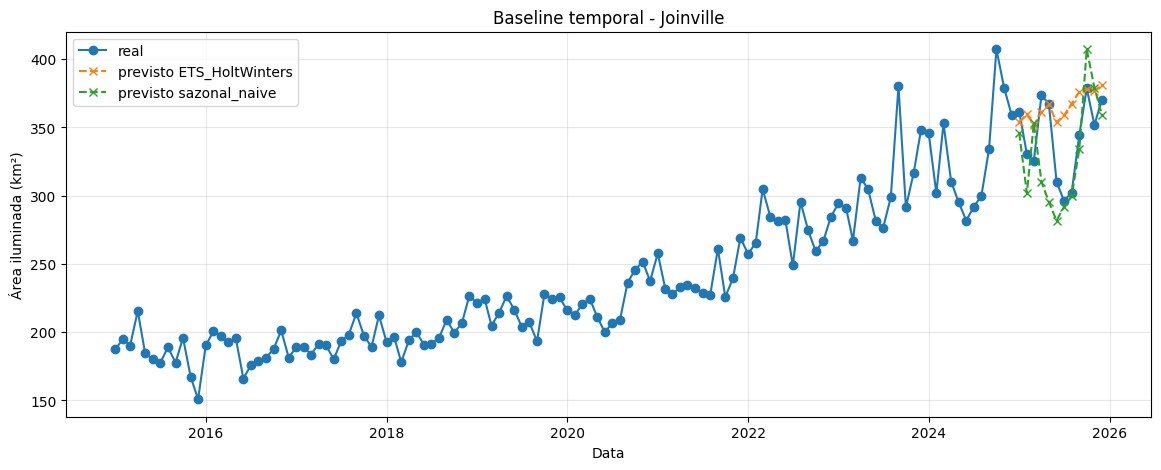

In [72]:
# Plotar real x previsto do baseline no teste de 2025
if len(previsoes_baseline_df) > 0:
    for regiao in previsoes_baseline_df['regiao'].unique():
        df_plot_real = serie_df[serie_df['regiao'] == regiao]
        df_plot_pred = previsoes_baseline_df[(previsoes_baseline_df['regiao'] == regiao) & (previsoes_baseline_df['split'] == 'teste_2025')]

        plt.figure(figsize=(14, 5))
        plt.plot(df_plot_real['data'], df_plot_real['area_iluminada_km2'], marker='o', label='real')
        for modelo, df_m in df_plot_pred.groupby('modelo'):
            plt.plot(df_m['data'], df_m['previsto'], marker='x', linestyle='--', label=f'previsto {modelo}')
        plt.title(f'Baseline temporal - {regiao}')
        plt.xlabel('Data')
        plt.ylabel('Área iluminada (km²)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

## 12. Preparar dados espaciais com modelo leve

Nesta versão, a parte espacial usa apenas `numpy`.

O modelo usa uma lógica simples:

- pega os **12 meses anteriores** de máscara iluminada;
- calcula a tendência recente de cada pixel;
- prevê o próximo mês como uma combinação entre o último mês observado e a tendência;
- avalia o resultado usando IoU;
- usa o modelo para prever os próximos meses de forma recursiva.

Isso é suficiente para um protótipo acadêmico funcional.


In [73]:
IMG_SIZE = 128
N_STEPS = 12
HORIZONTE = 1

print('Modelo espacial usado: tendência/persistência com NumPy')


def carregar_mascara_redimensionada(row, img_size=IMG_SIZE):
    params = params_regiao[row['regiao']]
    _, mascara, _ = gerar_mascara(row['tif_path'], params)

    mascara = cv2.resize(
        mascara.astype(np.float32),
        (img_size, img_size),
        interpolation=cv2.INTER_NEAREST
    )

    return mascara[..., None].astype(np.float32)


def preparar_sequencias(df, regioes=None, n_steps=N_STEPS, horizonte=HORIZONTE, img_size=IMG_SIZE):
    X, y, meta = [], [], []

    if regioes is None:
        regioes = sorted(df['regiao'].unique())

    for regiao in regioes:
        df_r = df[df['regiao'] == regiao].sort_values('data').reset_index(drop=True)

        if len(df_r) < n_steps + horizonte:
            print(f'Aviso: {regiao} tem apenas {len(df_r)} imagens. Pulando região.')
            continue

        mascaras = []

        for _, row in tqdm(df_r.iterrows(), total=len(df_r), desc=f'Carregando máscaras {regiao}'):
            mascaras.append(carregar_mascara_redimensionada(row, img_size=img_size))

        mascaras = np.stack(mascaras, axis=0)

        for i in range(0, len(mascaras) - n_steps - horizonte + 1):
            X.append(mascaras[i:i+n_steps])
            y.append(mascaras[i+n_steps+horizonte-1])
            meta.append({
                'regiao': regiao,
                'data_alvo': df_r.loc[i+n_steps+horizonte-1, 'data'],
                'ano_alvo': int(df_r.loc[i+n_steps+horizonte-1, 'ano']),
                'mes_alvo': int(df_r.loc[i+n_steps+horizonte-1, 'mes']),
            })

    meta_df = pd.DataFrame(meta, columns=['regiao', 'data_alvo', 'ano_alvo', 'mes_alvo'])

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), meta_df


X, y, meta_seq = preparar_sequencias(serie_df)

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)

display(meta_seq.head())

if len(X) == 0:
    raise ValueError(
        'Não foi possível montar sequências espaciais. '
        'Confira se cada região tem meses suficientes.'
    )

idx_train = meta_seq['ano_alvo'] <= 2023
idx_val = meta_seq['ano_alvo'] == 2024
idx_test = meta_seq['ano_alvo'] == 2025

X_train, y_train = X[idx_train.values], y[idx_train.values]
X_val, y_val = X[idx_val.values], y[idx_val.values]
X_test, y_test = X[idx_test.values], y[idx_test.values]
meta_test = meta_seq[idx_test.values].reset_index(drop=True)

print('Treino:', X_train.shape, y_train.shape)
print('Validação:', X_val.shape, y_val.shape)
print('Teste:', X_test.shape, y_test.shape)


Modelo espacial usado: tendência/persistência com NumPy


Carregando máscaras Joinville: 100%|██████████| 132/132 [00:00<00:00, 266.79it/s]


Formato de X: (475, 12, 128, 128, 1)
Formato de y: (475, 128, 128, 1)


,regiao,data_alvo,ano_alvo,mes_alvo
0,Blumenau,2016-01-01,2016,1
1,Blumenau,2016-02-01,2016,2
2,Blumenau,2016-03-01,2016,3
3,Blumenau,2016-04-01,2016,4
4,Blumenau,2016-05-01,2016,5


Treino: (380, 12, 128, 128, 1) (380, 128, 128, 1)
Validação: (48, 12, 128, 128, 1) (48, 128, 128, 1)
Teste: (47, 12, 128, 128, 1) (47, 128, 128, 1)


## 13. Modelo espacial de tendência/persistência

O modelo abaixo prevê:

```text
próximo_mapa = último_mapa + alpha * tendência_recente
```

Onde:

- `último_mapa` é a máscara do mês mais recente da sequência;
- `tendência_recente` é a média das diferenças entre os meses anteriores;
- `alpha` controla o quanto a tendência influencia a previsão.

O notebook testa vários valores de `alpha` e escolhe o melhor pela validação de 2024, quando houver dados.


In [74]:
def calcular_iou_np(y_true, y_pred, threshold=0.5):
    y_true_bin = (y_true >= 0.5).astype(np.uint8)
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)

    inter = np.logical_and(y_true_bin, y_pred_bin).sum()
    union = np.logical_or(y_true_bin, y_pred_bin).sum()

    return float((inter + 1e-6) / (union + 1e-6))


def iou_medio_np(y_true, y_pred, threshold=0.5):
    if len(y_true) == 0:
        return np.nan

    return float(np.mean([
        calcular_iou_np(y_true[i], y_pred[i], threshold=threshold)
        for i in range(len(y_true))
    ]))


class ModeloEspacialTendencia:
    def __init__(self, alpha=1.0, threshold=0.5):
        self.alpha = alpha
        self.threshold = threshold
        self.historico_ = None

    def _prever_com_alpha(self, X, alpha):
        ultimo_mes = X[:, -1]
        diferencas = np.diff(X, axis=1)
        tendencia = diferencas.mean(axis=1)

        pred = ultimo_mes + alpha * tendencia
        pred = np.clip(pred, 0.0, 1.0)

        return pred.astype(np.float32)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        candidatos_alpha = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

        if X_val is not None and len(X_val) > 0:
            X_ref = X_val
            y_ref = y_val
            nome_ref = 'validacao_2024'
        else:
            X_ref = X_train
            y_ref = y_train
            nome_ref = 'treino'

        historico = []
        melhor_alpha = self.alpha
        melhor_iou = -1

        for alpha in candidatos_alpha:
            pred = self._prever_com_alpha(X_ref, alpha)
            iou = iou_medio_np(y_ref, pred, threshold=self.threshold)

            historico.append({
                'alpha': alpha,
                'conjunto_usado': nome_ref,
                'iou_medio': iou,
            })

            if iou > melhor_iou:
                melhor_iou = iou
                melhor_alpha = alpha

        self.alpha = melhor_alpha
        self.historico_ = pd.DataFrame(historico)

        return self

    def predict(self, X, verbose=0):
        return self._prever_com_alpha(X, self.alpha)


modelo = ModeloEspacialTendencia(threshold=0.5)
modelo.fit(X_train, y_train, X_val, y_val)

print('Melhor alpha escolhido:', modelo.alpha)
display(modelo.historico_)


Melhor alpha escolhido: 0.0


,alpha,conjunto_usado,iou_medio
0,0.00,validacao_2024,0.820982
1,0.25,validacao_2024,0.820982
2,0.50,validacao_2024,0.820982
3,0.75,validacao_2024,0.820982
4,1.00,validacao_2024,0.820982
5,1.50,validacao_2024,0.820982
6,2.00,validacao_2024,0.820982


## 14. Avaliar o modelo espacial

Como este modelo não treina uma rede neural, esta etapa é rápida.

A avaliação usa IoU médio entre a máscara real e a máscara prevista.


,split,n,iou_medio,pixels_reais_medios,pixels_previstos_medios
0,treino_ate_2023,380,0.824113,1096.605263,1091.184211
1,validacao_2024,48,0.820982,1412.104167,1403.166667
2,teste_2025,47,0.846750,1439.170213,1437.957447


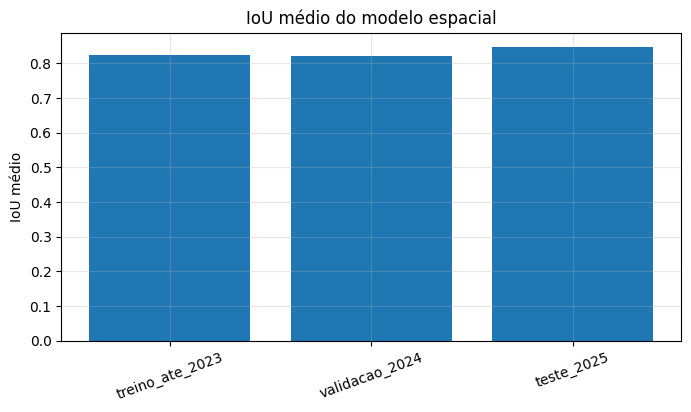

In [75]:
def avaliar_split(nome, X_split, y_split):
    if len(X_split) == 0:
        return {
            'split': nome,
            'n': 0,
            'iou_medio': np.nan,
            'pixels_reais_medios': np.nan,
            'pixels_previstos_medios': np.nan,
        }

    pred = modelo.predict(X_split)

    return {
        'split': nome,
        'n': len(X_split),
        'iou_medio': iou_medio_np(y_split, pred),
        'pixels_reais_medios': float((y_split >= 0.5).sum(axis=(1, 2, 3)).mean()),
        'pixels_previstos_medios': float((pred >= 0.5).sum(axis=(1, 2, 3)).mean()),
    }


avaliacao_modelo = pd.DataFrame([
    avaliar_split('treino_ate_2023', X_train, y_train),
    avaliar_split('validacao_2024', X_val, y_val),
    avaliar_split('teste_2025', X_test, y_test),
])

display(avaliacao_modelo)

plt.figure(figsize=(8, 4))

avaliacao_plot = avaliacao_modelo.dropna(subset=['iou_medio'])

plt.bar(avaliacao_plot['split'], avaliacao_plot['iou_medio'])
plt.title('IoU médio do modelo espacial')
plt.ylabel('IoU médio')
plt.xticks(rotation=20)
plt.grid(True, alpha=0.3)
plt.show()


## 15. Avaliar no ano de 2025 e visualizar mapas previstos

Aqui o notebook compara a máscara real de 2025 com a máscara prevista pelo modelo.


In [76]:
if len(X_test) > 0:
    y_pred_test = modelo.predict(X_test)

    metricas_espaciais = []

    for i in range(len(y_test)):
        metricas_espaciais.append({
            **meta_test.loc[i].to_dict(),
            'iou': calcular_iou_np(y_test[i], y_pred_test[i]),
            'pixels_reais': int((y_test[i] >= 0.5).sum()),
            'pixels_previstos': int((y_pred_test[i] >= 0.5).sum()),
        })

    metricas_espaciais_df = pd.DataFrame(metricas_espaciais)

    display(metricas_espaciais_df.groupby('regiao')['iou'].describe())

else:
    y_pred_test = None
    metricas_espaciais_df = pd.DataFrame()
    print('Sem dados de teste para 2025.')


,count,mean,std,min,25%,50%,75%,max
regiao,,,,,,,,
Blumenau,12.0,0.868953,0.009760,0.854726,0.865103,0.868947,0.870911,0.891825
Criciuma,12.0,0.836607,0.016569,0.813880,0.822068,0.836516,0.843639,0.870066
Florianopolis,11.0,0.875924,0.013947,0.852285,0.867706,0.872842,0.882847,0.903770
Joinville,12.0,0.807945,0.024511,0.760733,0.800939,0.804187,0.818673,0.844230


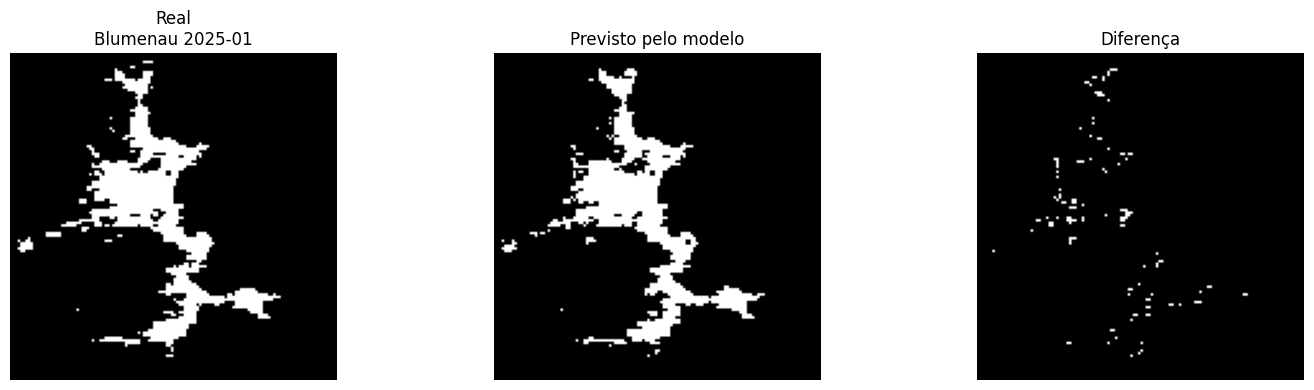

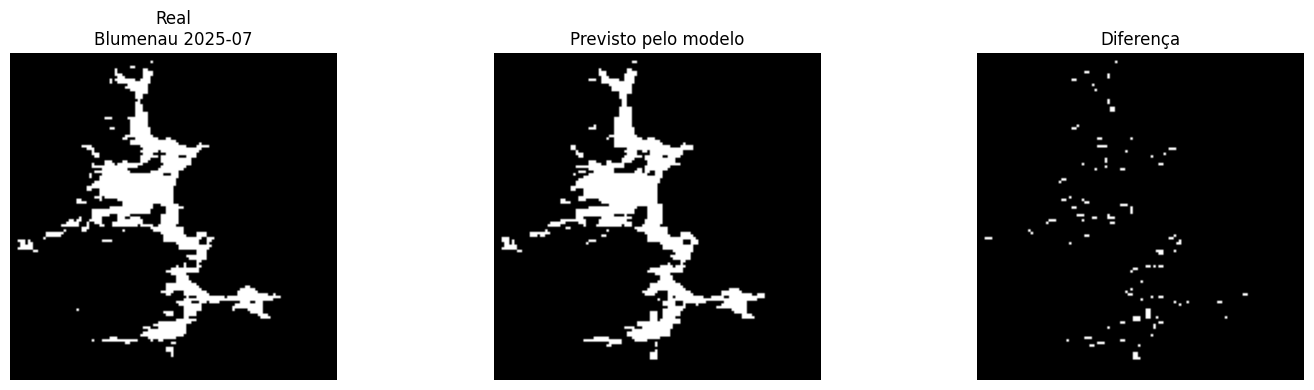

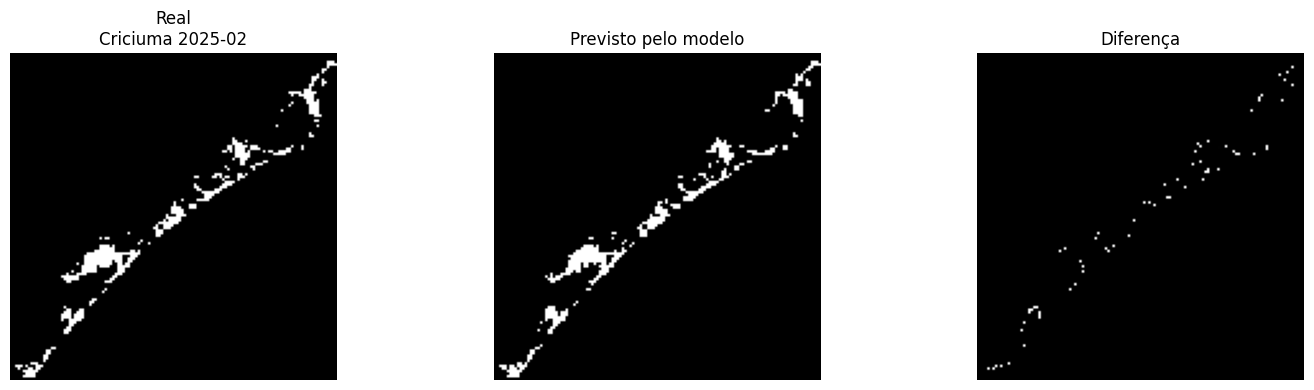

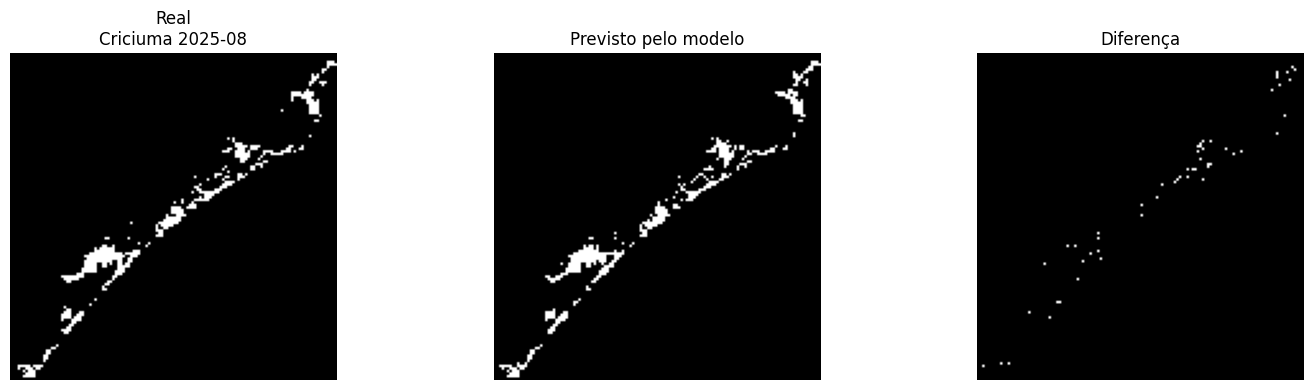

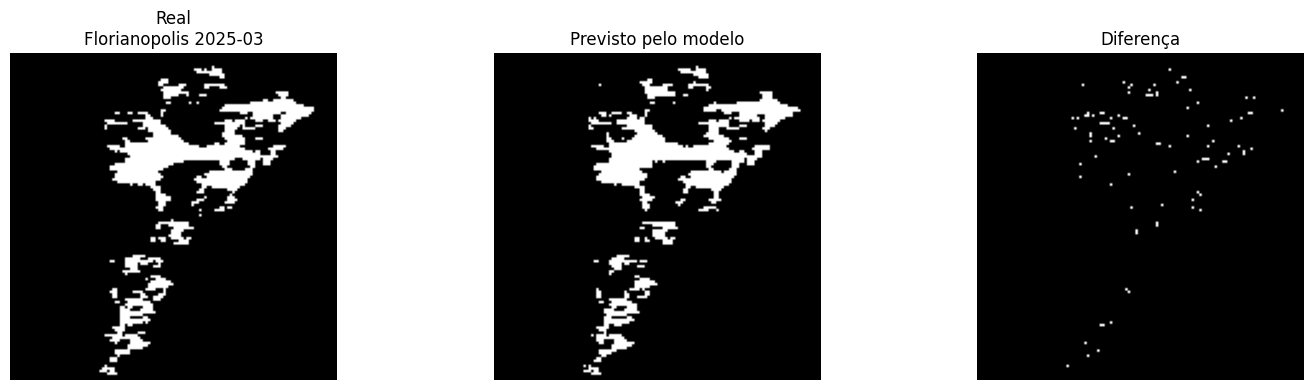

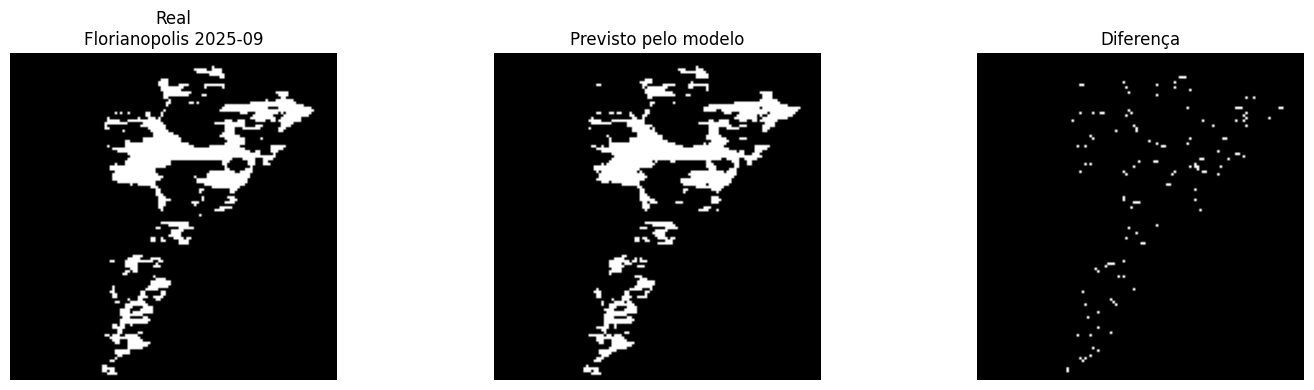

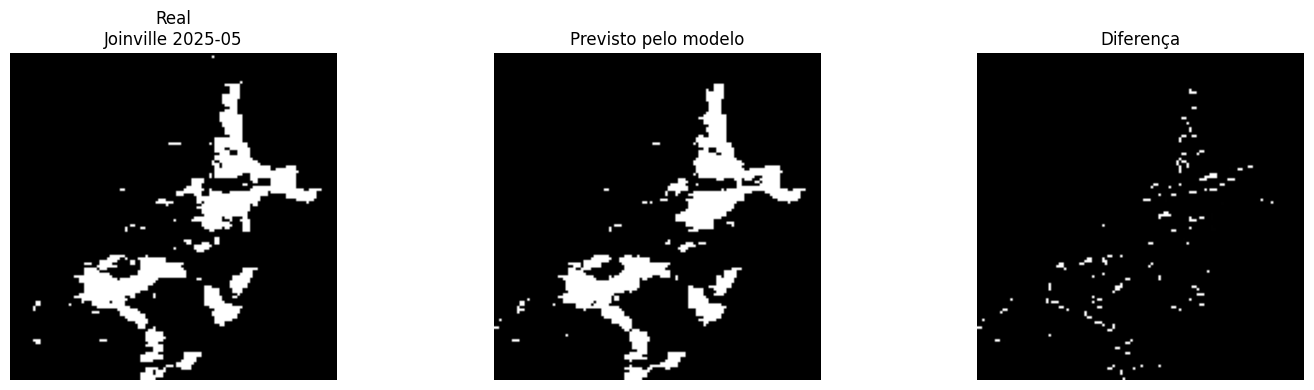

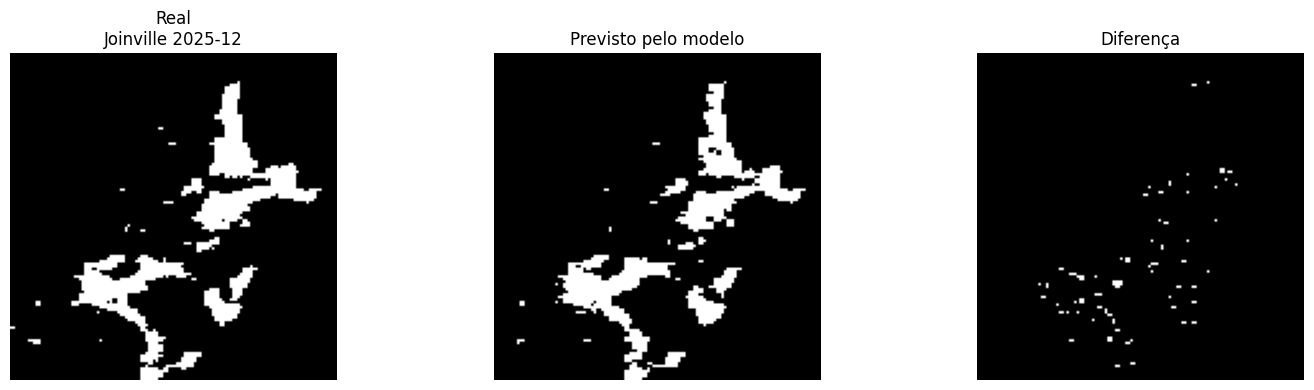

In [77]:
def mostrar_predicoes_teste(qtd=6):
    if y_pred_test is None or len(y_pred_test) == 0:
        print('Sem previsões de teste para mostrar.')
        return

    n = min(qtd, len(y_pred_test))
    indices = np.linspace(0, len(y_pred_test)-1, n).astype(int)

    for idx in indices:
        info = meta_test.loc[idx]

        pred_bin = (y_pred_test[idx, :, :, 0] >= 0.5).astype(np.uint8)
        real_bin = y_test[idx, :, :, 0].astype(np.uint8)
        erro = np.abs(real_bin - pred_bin)

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].imshow(real_bin, cmap='gray')
        axes[0].set_title(f'Real\n{info["regiao"]} {info["data_alvo"].strftime("%Y-%m")}')
        axes[0].axis('off')

        axes[1].imshow(pred_bin, cmap='gray')
        axes[1].set_title('Previsto pelo modelo')
        axes[1].axis('off')

        axes[2].imshow(erro, cmap='gray')
        axes[2].set_title('Diferença')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()


mostrar_predicoes_teste(qtd=8)


## 16. Prever mapas futuros recursivamente

A célula abaixo usa os últimos 12 meses observados de cada região e prevê os próximos 12 meses.

Depois de prever um mês, a previsão entra na janela para prever o mês seguinte.


In [78]:
def prever_futuro_regiao(regiao, meses=12, threshold=0.5):
    df_r = serie_df[serie_df['regiao'] == regiao].sort_values('data').reset_index(drop=True)

    if len(df_r) < N_STEPS:
        raise ValueError(f'Região {regiao} não tem meses suficientes.')

    ultimas = df_r.tail(N_STEPS)

    janela = []

    for _, row in ultimas.iterrows():
        janela.append(carregar_mascara_redimensionada(row))

    janela = np.stack(janela, axis=0)

    data_atual = df_r['data'].max()
    preds = []

    for k in range(meses):
        entrada = janela[None, ...]

        pred = modelo.predict(entrada)[0]
        pred_bin = (pred >= threshold).astype(np.float32)

        data_pred = data_atual + pd.DateOffset(months=k+1)

        preds.append({
            'data': data_pred,
            'pred_prob': pred,
            'pred_bin': pred_bin,
        })

        janela = np.concatenate([janela[1:], pred_bin[None, ...]], axis=0)

    return preds


previsoes_futuras = {}

for regiao in serie_df['regiao'].unique():
    previsoes_futuras[regiao] = prever_futuro_regiao(regiao, meses=12)
    print('Gerado futuro para:', regiao)


Gerado futuro para: Blumenau
Gerado futuro para: Criciuma
Gerado futuro para: Florianopolis
Gerado futuro para: Joinville


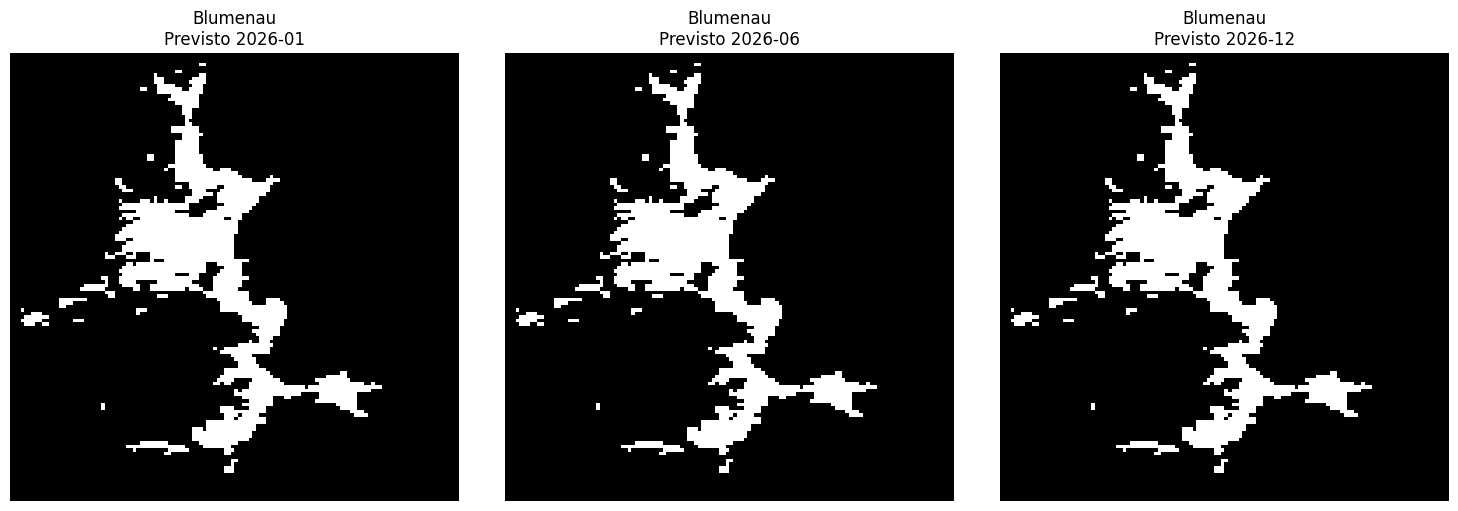

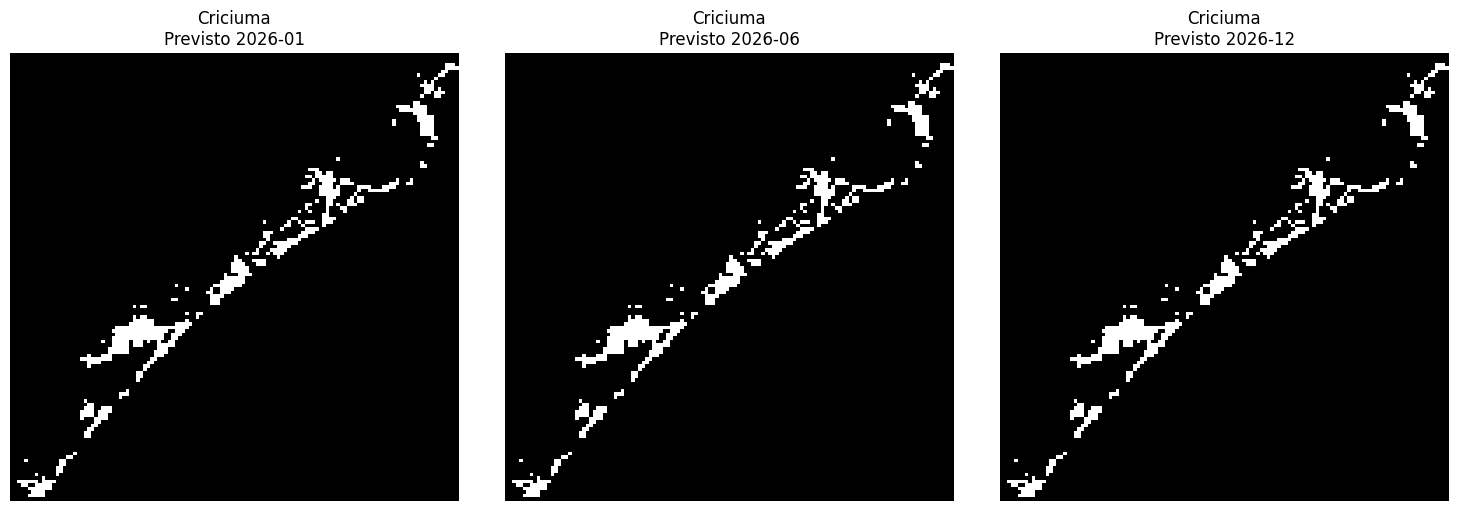

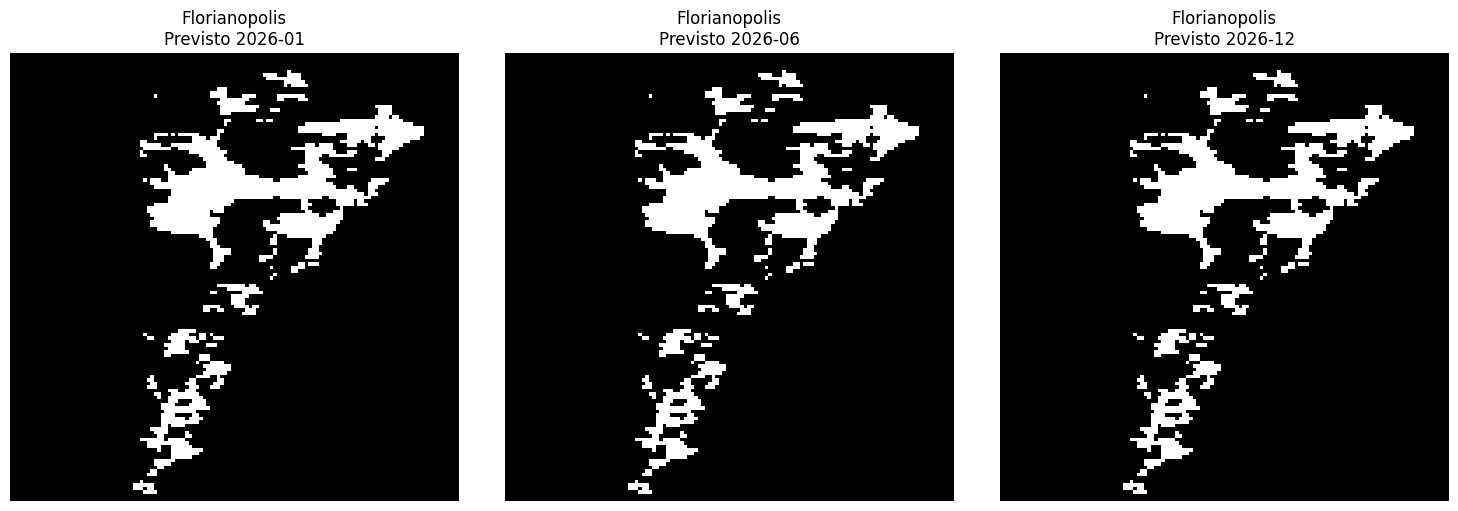

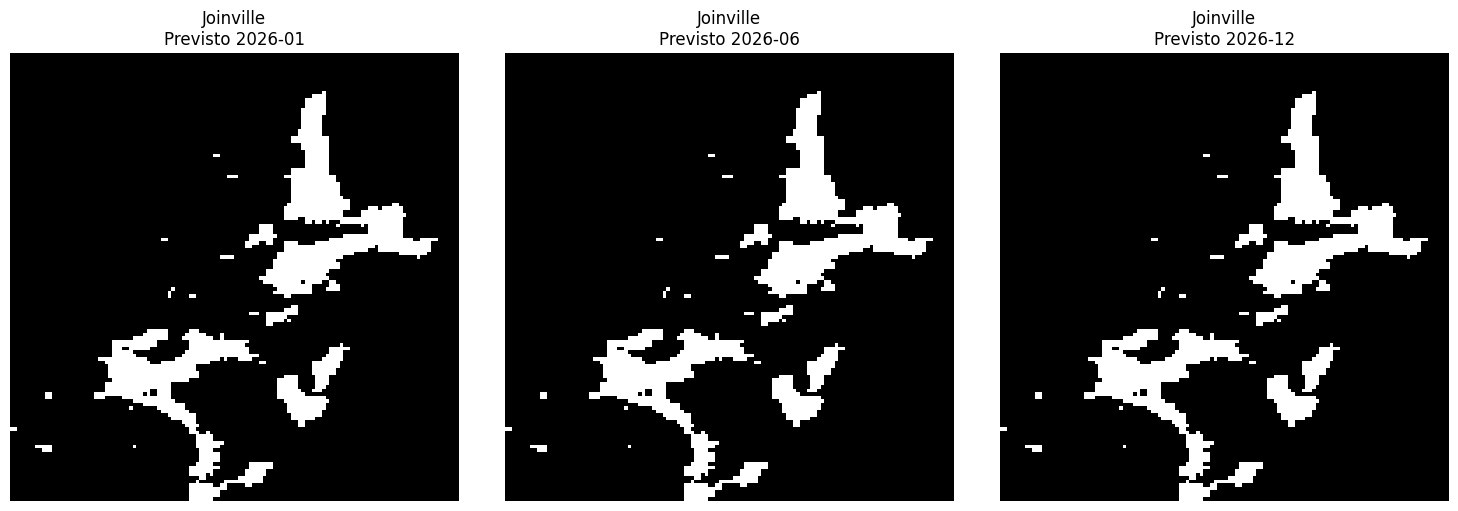

In [79]:
def visualizar_futuro(regiao, meses_mostrar=(1, 6, 12)):
    preds = previsoes_futuras[regiao]
    n = len(meses_mostrar)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for ax, m in zip(axes, meses_mostrar):
        item = preds[m-1]

        ax.imshow(item['pred_bin'][:, :, 0], cmap='gray')
        ax.set_title(f'{regiao}\nPrevisto {item["data"].strftime("%Y-%m")}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


for regiao in serie_df['regiao'].unique():
    visualizar_futuro(regiao)


## 17. Série futura de área iluminada prevista pelo modelo espacial

Como o modelo espacial prevê uma máscara `64x64`, a área futura é uma aproximação.

Para o relatório, use essa saída como indicador de tendência e complemente com o baseline temporal.


,regiao,data,pixels_previstos_resize,area_prevista_km2_aprox
0,Blumenau,2026-01-01,1916,513.589151
1,Blumenau,2026-02-01,1916,513.589151
2,Blumenau,2026-03-01,1916,513.589151
3,Blumenau,2026-04-01,1916,513.589151
4,Blumenau,2026-05-01,1916,513.589151


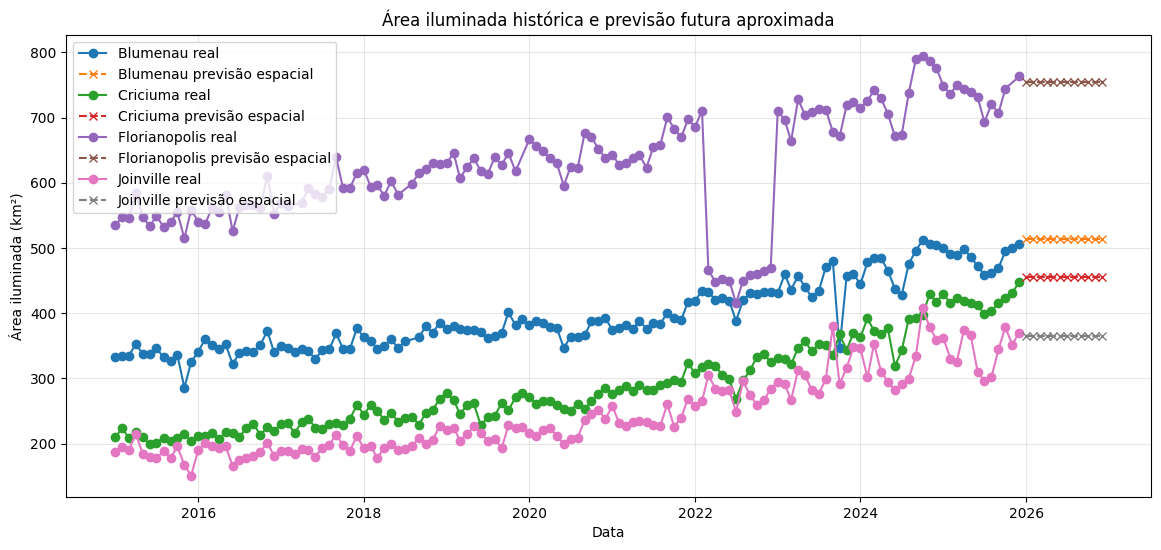

Previsão futura salva em: c:\Users\thomh\Desktop\Pastas\FURB\2026.1\Processamento de Imagens\processamento-de-imagens-luzes-noturnas\src\resultados\previsao_futura_modelo_espacial.csv


In [80]:
linhas_futuro = []

for regiao, preds in previsoes_futuras.items():
    df_r = serie_df[serie_df['regiao'] == regiao].sort_values('data')
    row_last = df_r.iloc[-1]

    area_total_original = row_last['height'] * row_last['width'] * row_last['pixel_area_km2']
    area_pixel_resize = area_total_original / (IMG_SIZE * IMG_SIZE)

    for item in preds:
        pix = int(item['pred_bin'][:, :, 0].sum())

        linhas_futuro.append({
            'regiao': regiao,
            'data': item['data'],
            'pixels_previstos_resize': pix,
            'area_prevista_km2_aprox': pix * area_pixel_resize,
        })

futuro_df = pd.DataFrame(linhas_futuro)

display(futuro_df.head())

plt.figure(figsize=(14, 6))

for regiao in serie_df['regiao'].unique():
    hist = serie_df[serie_df['regiao'] == regiao]
    fut = futuro_df[futuro_df['regiao'] == regiao]

    plt.plot(
        hist['data'],
        hist['area_iluminada_km2'],
        marker='o',
        label=f'{regiao} real'
    )

    plt.plot(
        fut['data'],
        fut['area_prevista_km2_aprox'],
        marker='x',
        linestyle='--',
        label=f'{regiao} previsão espacial'
    )

plt.title('Área iluminada histórica e previsão futura aproximada')
plt.xlabel('Data')
plt.ylabel('Área iluminada (km²)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

futuro_csv = OUTPUT_DIR / 'previsao_futura_modelo_espacial.csv'
futuro_df.to_csv(futuro_csv, index=False)

print('Previsão futura salva em:', futuro_csv)


## 18. Como apresentar no trabalho

Sugestão de estrutura para o relatório/apresentação:

1. **Problema:** prever expansão espacial da área iluminada em regiões litorâneas.
2. **Dados:** imagens mensais VIIRS NTL `.tif`, 2015–2025, 4 regiões, organizadas em pastas por ano.
3. **Organização dos dados:** pasta raiz com subpastas `2015`, `2016`, ..., `2025`; a região é extraída do nome do arquivo.
4. **Arquivos auxiliares:** `.aux.xml` são opcionais; podem existir só para algumas regiões e são usados apenas para auditoria.
5. **Pré-processamento:** leitura raster, `log1p`, normalização robusta, limiar fixo por região.
6. **Produto intermediário:** máscaras binárias de área iluminada.
7. **Baseline:** previsão temporal da área iluminada por região.
8. **Modelo espacial:** tendência/persistência com janela de 12 meses.
9. **Avaliação:** MAE/RMSE/MAPE para área e IoU para máscaras.
10. **Resultado final:** mapas previstos e curva futura de área iluminada.

Para a entrega desta semana, priorize até a seção 11. Para a entrega final, inclua as seções 12–17.


## 19. Próximas melhorias possíveis

- testar limiares diferentes e comparar a estabilidade;
- treinar um modelo por região e comparar com o modelo genérico;
- usar média anual em vez de mês a mês para reduzir ruído;
- adicionar relevo, distância da costa ou distância de áreas já iluminadas como canais extras;
- trocar máscara binária por previsão de radiância contínua normalizada.